## Symmetric notch filter (notches frequencies f and also -f)

In [1]:
import numpy as np
from scipy import signal
import scipy.fft as spfft
from numpy.polynomial.polynomial import polyval
import matplotlib.pyplot as plt

In [24]:
# Interactive plotting.  Comment out this next line if inline plots are desired.
#%matplotlib qt

In [3]:
# Function to create IQ representation of sine wave at a given freq for a given sample rate.
#
# Inputs: 
#  freq - frequency of sine wave, Hz
#  amp  - amplitude, arbitrary units
#  fs   - sampling rate of sine wave, Hz
#  no_samps - number of samples to generate
#
# Returns:
#  complex (IQ) representation of sine wave with input parameters.
#
# Affects: None
#
# Exceptions: AssertionError if freq >= fs.
#
def create_sig(freq, amp, fs, no_samps):
    assert freq < fs
    delta_t = 1.0 / fs
    x = np.linspace(0.0, no_samps * delta_t, no_samps, endpoint=False)
    iq = amp * np.exp(1j * freq * 2.0 * np.pi * x)
    return iq

In [4]:
# Function to plot the frequency domain spectrum of a complex signal.
#
# Inputs: 
#  y - complex time domain signal to be plotted
#  fs - sampling rate, Hz
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)
#  ylim - y axis plot limits: (min, max)
#
# Returns:
#  Plot of frequency domain representation of signal.
#
# Affects: None
#
# Exceptions: None
#
def spec_plot(y, fs, ttext, xlim, ylim):
    delta_t = 1.0 / fs
    no_samps = len(y)
    yf = spfft.fft(y)
    xf = spfft.fftfreq(no_samps, delta_t)
    xf_shift = spfft.fftshift(xf)
    yf_shift = spfft.fftshift(yf)
    plt.figure()
    plt.plot(xf_shift, 1.0/no_samps * np.abs(yf_shift))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Spectral amplitude')
    plt.title(ttext)
    plt.grid()
    plt.show()

In [5]:
# Function to plot the frequency domain spectrum of a complex signal
#  on a logarithmic (dB) scale.
#
# Inputs: 
#  y - complex time domain signal to be plotted
#  fs - sampling rate, Hz
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max).  None=autoscale
#  ylim - y axis plot limits: (min, max).  None=autoscale
#
# Returns:
#  Plot of frequency domain representation of signal.
#
# Affects: None
#
# Exceptions: None
#
def spec_plot_dB(y, fs, ttext, xlim=None, ylim=None):
    delta_t = 1.0 / fs
    no_samps = len(y)
    yf = spfft.fft(y)
    xf = spfft.fftfreq(no_samps, delta_t)
    xf_shift = spfft.fftshift(xf)
    yf_shift = spfft.fftshift(yf)
    plt.figure()
    plt.plot(xf_shift, 10*np.log10(1.0/no_samps * np.abs(yf_shift) + 1e-10)) # set a floor for values close to zero
    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    plt.xlabel('Frequency, Hz')
    plt.ylabel('Relative spectral amplitude, dB')
    plt.title(ttext)
    plt.grid()
    plt.show()

In [6]:
# Function to plot the frequency domain response of a filter.
#
# Inputs: 
#  w - array of frequencies at which filter response h was computed.
#  H - array of frequency response, as complex numbers.
#  ttext - title of plot
#  xlim - x axis plot limits: (min, max)
#  ylim - y axis plot limits: (min, max)
#
# Returns:
#  Plot of abs(filter response) vs. real frequency.
#
# Affects: None
#
# Exceptions: None
#
def plot_filt(w, H, ttext, xlim, ylim):
    plt.figure()
    plt.plot(np.real(w), np.abs(H))
    plt.ylim(ylim)
    plt.xlim(xlim)
    plt.xlabel("Frequency, Hz")
    plt.ylabel("Magnitude")
    plt.title(ttext)
    plt.grid()
    plt.show()

In [7]:
# Function to design a linear infinite impulse response (IIR) symmetric notch filter using pole-zero placement.
#
# Inputs: 
#  notch_freq - Frequency of notch in Hz
#  q_factor - Quality factor of the notch.  Smaller q_factor = wider notch.
#  sample_rate - Sampling rate of filter, Hz
#
# Returns:
#  (b, a) where
#  b - Filter numerator coefficients
#  a - Filter denominator coefficients
#
# Affects: None
#
# Exceptions: None
#
def filt_def_notch(notch_freq, q_factor, sample_rate):

    # fixed number of taps for filter order
    num_taps = 251 # Filter order (must be odd for linear phase, which helps in design)

    # design symmetric notch filter
    #  (see "iirnotch" documentation)
    #  Note: this is a standard python function - notice the symmetric quality
    b, a = signal.iirnotch(notch_freq, q_factor, sample_rate)

    # Filter is complete    
    return b, a    

In [8]:
# Function to calculate filter frequency response of a FIR or IIR filter.
#  Note: this is for visualization purposes only - the time domain "b" and "a" coefficients
#   do the work here for the actual filtering further down, through the "lfilter" operator.
#
# Inputs: 
#  b - numerator coefficients of filter
#  a  - denominator coefficients of filter
#  sample_rate   - Sampling rate of filter, Hz
#  
# Returns:
#  freqs - Frequencies at which filter response was computed, Hz
#      range: [-sample_rate/2, +sample_rate/2)
#  H - Filter frequency response, as complex numbers
#
# Affects: None
#
def comp_fil_response(b, a, sample_rate):
    
    # Directly compute filter response.
    #
    # For more background on why the frequencies are first computed as radians on (-pi, pi] range, 
    # consult a DSP textbook for an explanation of z-transforms - e.g.
    #    Oppenheim & Schafer, Discrete-Time Signal Processing (3rd ed.)
    #    Proakis & Manolakis, Digital Signal Processing: Principles, Algorithms, and Applications
    #    Lyons, Understanding Digital Signal Processing
    #
    
    # Reverse the coefficients due to library incompatibilities:
    #
    # At present, "polyval" requires ordering of numerator and denominator coefficients 
    # from the lowest degree (i.e. the constant term) up to the highest degree.
    # However, the filtering operator lfilter() expect the numerator and denominator 
    # in highest to lowest degree form.
    #
    # This is true for numpy version 1.22.2, the version used at the time of writing,
    #   and for scipy version 1.8.0.  It may change in the future; beware.
    #  
    b = b[::-1]
    a = a[::-1]
    
    # compute at 2048 frequencies for good fidelity
    w = np.linspace(-np.pi, np.pi, 2048, endpoint=False)
    
    # main loop
    z = np.exp(1j * w)
    num = np.zeros(len(z), dtype=np.complex64)
    den = np.zeros(len(z), dtype=np.complex64)
    for ii in range(len(z)):
        num[ii] = polyval(z[ii], b)
        den[ii] = polyval(z[ii], a)
    H = num / den

    # convert frequencies to Hz rather than radians
    freqs = w * sample_rate / (2 * np.pi) # convert from radians to freq

    return freqs, H

In [9]:
fs = 32000       # sample rate
no_samps = 32000 # number of samples
cf = 10000       # center frequenccy

In [10]:
# 4 signal frequencies with different amplitudes
sig_1_f = 8000
sig_1_a = 0.7
sig_2_f = 9000
sig_2_a = 0.8
sig_3_f = 11000
sig_3_a = 0.9
sig_4_f = 12000
sig_4_a = 1.0

In [11]:
# shift frequencies from center frequency to baseband
b_sig_1_f = 8000 - cf
b_sig_1_a = 0.7
b_sig_2_f = 9000 - cf
b_sig_2_a = 0.8
b_sig_3_f = 11000 - cf
b_sig_3_a = 0.9
b_sig_4_f = 12000 - cf
b_sig_4_a = 1.0

In [12]:
# create signals individually
b_sig_1 = create_sig(b_sig_1_f, sig_1_a, fs, no_samps)
b_sig_2 = create_sig(b_sig_2_f, sig_2_a, fs, no_samps)
b_sig_3 = create_sig(b_sig_3_f, sig_3_a, fs, no_samps)
b_sig_4 = create_sig(b_sig_4_f, sig_4_a, fs, no_samps)
# sum them to create input complex signal
b_sig = b_sig_1 + b_sig_2 + b_sig_3 + b_sig_4

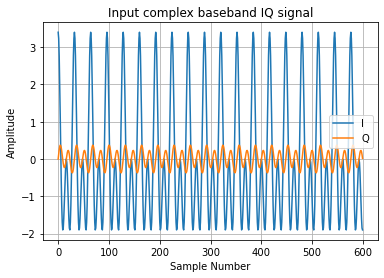

In [13]:
# plot 600 samples of time series before filter
plt.figure()
plt.plot(np.real(b_sig[0:600]),label='I')
plt.plot(np.imag(b_sig[0:600]),label='Q')
plt.legend()
plt.grid()
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.title('Input complex baseband IQ signal')
plt.show()

In [14]:
# Frequency plot limits will be the same for all plots following this point
ylim = (0, 1.05)
xlim = (-3000, 3000)

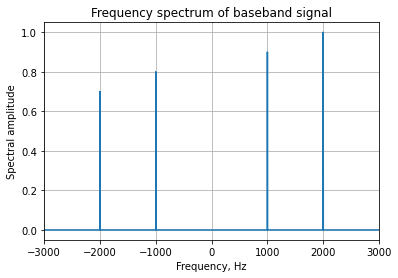

In [15]:
# plot spectrum of four baseband signals
spec_plot(b_sig, fs, 
          'Frequency spectrum of baseband signal', xlim, None)

In [16]:
# design filter with frequency of notch = 1000 Hz and narrow width
b, a = filt_def_notch(1000, 30, fs)

In [17]:
# compute filter frequency response
freqs, H = comp_fil_response(b, a, fs)

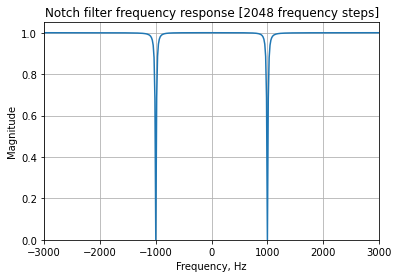

In [18]:
# plot frequency domain filter response
plot_filt(freqs, H, 
          'Notch filter frequency response [%i frequency steps]' % (len(freqs)), 
          xlim, ylim)

In [19]:
print('Filter response coefficients in time domain:')
print('Numerator: ' + str(b))
print('Denominator: ' + str(a))

Filter response coefficients in time domain:
Numerator: [ 0.99673817 -1.95517225  0.99673817]
Denominator: [ 1.         -1.95517225  0.99347634]


In [20]:
# apply the iir filter
# apply time-domain filter to complex input signal
y = signal.lfilter(b, a, b_sig)

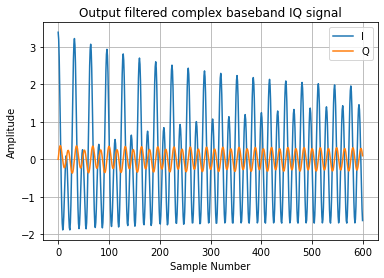

In [21]:
# plot 600 samples of time series after filter
plt.figure()
plt.plot(np.real(y[0:600]),label='I')
plt.plot(np.imag(y[0:600]),label='Q')
plt.legend()
plt.grid()
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.title('Output filtered complex baseband IQ signal')
plt.show()

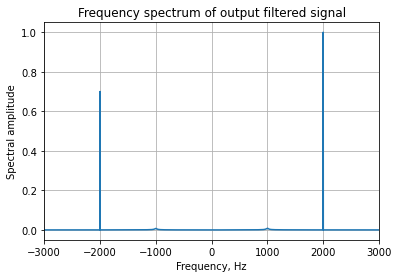

In [22]:
# plot spectrum of output filtered signal
spec_plot(y, fs, 
          'Frequency spectrum of output filtered signal', xlim, None)

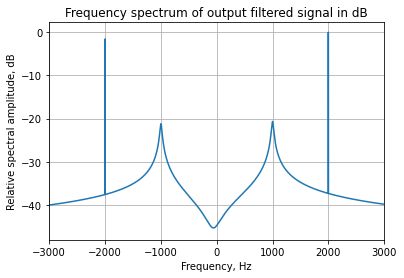

In [23]:
# plot spectrum of output filtered signal on a dB scale
#   Note: the notch filter's taps are not sufficient to completely remove
#   the signal at the notch frequencies.  
#
# Bonus question:
#   How would you increase signal suppression at the notch frequencies?
#
spec_plot_dB(y, fs, 
            'Frequency spectrum of output filtered signal in dB', xlim, None)